This is a Jupyter Notebook for my code on the best possible Tudat Model for the asteroids.

In [2]:
# Goal: Simulate an accurate orbit and perihelion precession for TU3 
# (Then it can be applied to the other asteroids)

# Chapter 1: Create a model with all the necessary bodies

# Chapter 2: Apply General Relativity & Solar quadrupole Moment 
# Also apply the Yarkowsky effect
# For this argue why these effects are the only relevant

# -----------------------------------------------------------------------------

# Firstly, follow the example for Solar System Propagation using Multi-Body Dynamics

# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator
from tudatpy import constants
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime
from tudatpy.astro import element_conversion
# For the minor planets 
from tudatpy.data import horizons

In [3]:
# Step 1: Setup Conditions/ Basic Conditions

# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs (total simulation time of 5 years)
# Start dat = 25th of April 2004 (arbitrary choice)
# Tudat works in J2000, so use seconds
simulation_start_epoch = DateTime(2000, 1, 1).to_epoch()
simulation_end_epoch   = simulation_start_epoch + 15 * constants.JULIAN_YEAR


# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create = [
    "Sun",
    "Earth",
    "Mercury",
    "Venus",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune"
]

# The 21 smaller bodies do not exist inside of SPICE and therefore their mu has to be manually added
# Create a dictionary to store the names, ID numbers and mu (GM in km3/s2) of the asteroids 

# Will check later if I need to add e.g. radius, radiation or time of orbit around the Sun etc.

smaller_bodies = {
    "Ceres": [1, 62.10], 
    "Pallas": [2, 13.73],
    # "Juno": [3, 1.61],
    # "Vesta": [4, 17.38],
    # "Hebe": [6, 0.89],
    # "Iris": [7, 0.73],
    # "Flora": [8, 0.27],
    # "Metis": [9, 0.44],
    # "Hygiea": [10, 5.97],
    # "Irene": [14, 0.25],
    # "Eunomia": [15, 1.88],
    # "Psyche": [16, 1.65],
    # "Fortuna": [19, 0.42],
    # "Thalia": [23, 0.15],
    # "Amphitrite": [29, 0.98],
    # "Daphne": [41, 0.56],
    # "Europa": [52, 1.48],
    # "Bamberga": [324, 0.71],
    # "Davida": [511, 1.14],
    # "Herculina": [532, 0.66],
    # "Interamnia": [704, 2.65]
}

# Extract only the names 
# This is so that the list of all bodies can be created
smaller_bodies_list = list(smaller_bodies.keys())


# Manually add 1998 TU3
asteroid_name = "1998-TU3"


# Combine all bodies into one large list
bodies_to_create = larger_bodies_to_create + smaller_bodies_list + [asteroid_name]
bodies_to_propagate = asteroid_name     # I only propagate TU3, I pull the other values from pre-existing ephemeris


# ----------------------------
# Create bodies in simulation.

# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB', 
    base_frame_orientation = 'ECLIPJ2000')

# To avoid the issue of calling for coordinates that don't exist in the ephermeris
# Add a buffer time

buffer_time = 5 * constants.JULIAN_DAY

# A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon

for i, (name, data) in enumerate(smaller_bodies.items(), start=1):

    # Extract asteroid properties
    ast_id = data[0]
    ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units)

    try:

        # --------------------------------------------
        # Extracting the ephemeris from JPL Horizons (not SPICE)

        # ephemeris_settings_ast = environment_setup.ephemeris.jpl_horizons(
        #     horizons_query = str(ast_id),
        #     horizons_location = "@0",       # This sets the center at the SSB (an exact command)
        #     frame_origin = "SSB",
        #     frame_orientation = "ECLIPJ2000",    # Debate between ECLIPJ2000 and J2000
        #     epoch_start = simulation_start_epoch - buffer_time,
        #     epoch_end = simulation_end_epoch + buffer_time,
        #     epoch_step = "1d",              # 1 day step
        #     extended_query = True           # Helps Horizon resolve asteroids' IDs more robustly
        # )


        # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
        DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
            frame_origin = 'SSB', 
            frame_orientation = 'ECLIPJ2000', 
            body_name_to_use = name)


        # Create empty slots, then insert the asteroids
        body_settings.add_empty_settings(name)
        # Assign ephemeris
        body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast

        # Assign gravity field (central function that manually adds the mu)
        body_settings.get(name).gravity_field_settings = (
            environment_setup.gravity_field.central(ast_mu)
        )

        print(f" {i}. Successfully configured {name} (ID: {ast_id})")

    except Exception as e:

        print(f"Could not fetch data for {name}: {e}")

# Manually add empty settings for TU3
body_settings.add_empty_settings(asteroid_name)

# Thus, the environment becomes:
body_system = environment_setup.create_system_of_bodies(body_settings)


 1. Successfully configured Ceres (ID: 1)
 2. Successfully configured Pallas (ID: 2)


In [4]:

# Step 3: Create Propagation Setup (barycentric and hierarchic)

# # Central bodies for barycentric propagation
# # Ensures that every body propagates around the Solar System's Barycenter 
# central_bodies_barycentric = ["SSB"] * len(bodies_to_create)

# # Central bodies for hierarchical parent body propagation
# # Assigns each body to their local parent body
# central_bodies_hierarchical = []
# for body_name in bodies_to_create:
    
#     if body_name == "Sun":
#         central_bodies_hierarchical.append("SSB")
#     else:
#         # Planets and asteroids are assigned to the Sun
#         central_bodies_hierarchical.append("Sun")




# Step 3: Create the Propagation Setup

bodies_to_propagate = ["1998-TU3"]

central_bodies = ["SSB"]

In [5]:

# Step 4: Define the accelerations acting on TU3 (for now)

# The planets
accelerations_planets = {
    "Sun": [
        propagation_setup.acceleration.point_mass_gravity(),
        # propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # propagation_setup.acceleration.yarkovsky(-2.65*10**(-14)),                      # The Yarkovsky parameter (Supposed to be added to the asteroid in the code?)
        # propagation_setup.acceleration.spherical_harmonic()                           # The solar quadrupole moment

    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# The asteroids

accelerations_asteroids = {
    
    asteroid_name: [
        propagation_setup.acceleration.point_mass_gravity()
    ]
    for asteroid_name in smaller_bodies_list
}

# Merge dictionaries
accelerations_merged = (
    accelerations_planets |
    accelerations_asteroids
)

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict = {
    "1998-TU3": accelerations_merged
}



# Step 5: Define the Initial States of Each Body
# This is where we mix SPICE data (for the planets) with Keplerian data (the asteroid)

# Convert acceleration mappings into acceleration models for both propagation variants
# for propagation_variant in ["barycentric", "hierarchical"]:
#     central_bodies = central_bodies_barycentric if propagation_variant == "barycentric" else central_bodies_hierarchical

# Now the planets aren't propagated anymore, so then they don't need an initial state

    # ii. Define TU3 state from Keplerian Elements 
    # The different coordinates are converted to Cartesian coordinates
    # Use the Sun's gravitational parameter for the conversion

sun_gravitational_parameter = body_system.get("Sun").gravitational_parameter

# Grabbing the initial state at 2000-01-01 from JPL with cartesian_to_keplarian() (in astro)

# Cartesian state vector
cartesian_elements = np.array([
    [4.543863572576185E+07 * 1e3],   # X  [m]
    [-9.673019712424231E+07 * 1e3],  # Y  [m]
    [-2.313075952057116E+06 * 1e3],  # Z  [m]
    [3.661410298575712E+01 * 1e3],   # VX [m/s]
    [-1.757686929389374E+00 * 1e3],  # VY [m/s]
    [-3.350242409196601E+00 * 1e3]   # VZ [m/s]
], dtype=np.float64)


test_initial_TU3_array = element_conversion.cartesian_to_keplerian(
    cartesian_elements = cartesian_elements,
    gravitational_parameter = sun_gravitational_parameter
    )

print("Keplerian Elements:")
print(test_initial_TU3_array)
print(test_initial_TU3_array[0])
print(test_initial_TU3_array[2])

    # ---------------------------------
    # New initial condition

initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter = sun_gravitational_parameter,
    semi_major_axis = test_initial_TU3_array[0],                 #meters
    eccentricity = test_initial_TU3_array[1],                    #unitless
    inclination = test_initial_TU3_array[2],                     # cartesian_to_keplerian returns angles in radians
    argument_of_periapsis = test_initial_TU3_array[3],
    longitude_of_ascending_node = test_initial_TU3_array[4],
    true_anomaly = test_initial_TU3_array[5],                
)
    # ---------------------------------

    # Old initial state from JPL at 2025-Nov-21
    # initial_state_tu3 = element_conversion.keplerian_to_cartesian_elementwise(
    #     gravitational_parameter = sun_gravitational_parameter,
    #     semi_major_axis = 117815568541,                                 # meters
    #     eccentricity = 0.4836694929440215,                              # unitless
    #     inclination = np.radians(5.415250040031074),                    # radians
    #     argument_of_periapsis = np.radians(84.99253804349257),          # rad
    #     longitude_of_ascending_node = np.radians(101.8786744779986),    # rad
    #     true_anomaly = 2.2486890775e+00,                                # rad, calculated with e, M, and E.
    # )


system_initial_state = initial_state_TU3


# Step 6: Create the conditions for propagation:

# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch) # 15 years after the epoch begins

# Create numerical integrator settings
fixed_step_size = 3600.0    # each hour
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, 
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78     # Range-Kutta 78 instead of 4 (more precise as I do 1 hour steps for many years)
)


# Create the acceleration model
acceleration_models = (
    propagation_setup.create_acceleration_models(
        body_system,
        acceleration_dict,
        bodies_to_propagate,
        central_bodies
    )
)



# Propagating TU3 with the created system
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)



# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    body_system, propagator_settings
)

# Extract the resulting state history and convert it to an ndarray
states_TU3 = dynamics_simulator.propagation_results.state_history
states_array_TU3 = result2array(states_TU3)

Keplerian Elements:
[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
117640977822.613
0.09419482774380611


In [6]:
# print(states_TU3[0])
# print(states_array_TU3[0]) # added time column in the array

Now, to print the values:

In [7]:
# Extract the times 
times = states_array_TU3[:,0]

In [8]:
# To check what the heck the asteroids' coordinates look like:

asteroid_ephemerides = {}

for asteroid_name in smaller_bodies_list:

    asteroid_states = np.array([
        body_system.get(asteroid_name)
        .ephemeris
        .cartesian_state(time)

        for time in times
    ])

    asteroid_ephemerides[asteroid_name] = asteroid_states

In [9]:
print(
    f"""
Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: \n{
    states_TU3[simulation_start_epoch][:3] / 1E3}
The initial velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_start_epoch][3:] / 1E3}
\nAfter {simulation_end_epoch} seconds the position vector of TU3 is [km]: \n{
    states_TU3[simulation_end_epoch][:3] / 1E3}
And the velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_end_epoch][3:] / 1E3}
    """
)

print(asteroid_ephemerides["Ceres"][0])
print(asteroid_ephemerides["Ceres"][100])



Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: 
[ 45438635.72576186 -96730197.12424232  -2313075.95205713]
The initial velocity vector of TU3 is [km/s]: 
[36.61410299 -1.75768693 -3.35024241]

After 473364000.0 seconds the position vector of TU3 is [km]: 
[ 1.51157485e+08  7.01082821e+07 -1.53892933e+07]
And the velocity vector of TU3 is [km/s]: 
[-13.89388537  16.38155495   0.95920496]
    
[-3.57010057e+11  1.18584692e+11  6.92954666e+10 -6.19662282e+03
 -1.83419389e+04  5.77893191e+02]
[-3.59185663e+11  1.11963530e+11  6.94927832e+10 -5.88978929e+03
 -1.84413347e+04  5.18287124e+02]


In [10]:

# Extract the 21 asteroids:

asteroid_ephemerides = {}

for asteroid_name in smaller_bodies_list:

    asteroid_states = np.array([

        body_system.get(asteroid_name)
        .ephemeris
        .cartesian_state(time)

        for time in times

    ])

    asteroid_ephemerides[asteroid_name] = asteroid_states

    # The planets are extracted similarly when plotting the Solar System


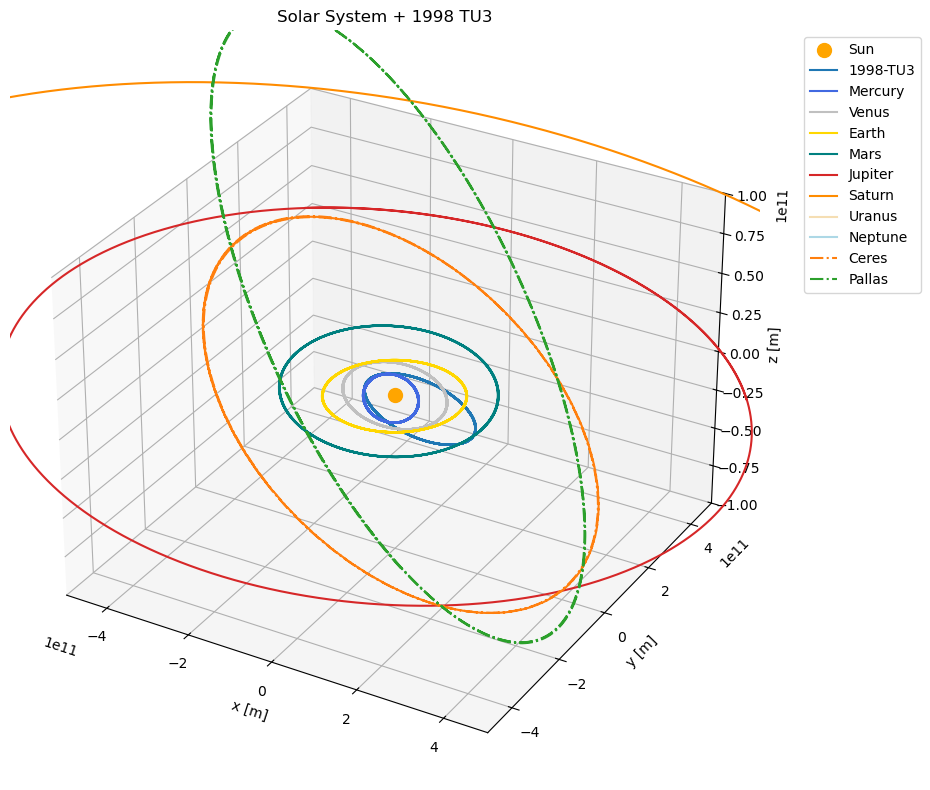

In [11]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Solar System + 1998 TU3')

ax.scatter(0,0,0,s=100,label="Sun", color='orange')

ax.plot(
    states_array_TU3[:,1],
    states_array_TU3[:,2],
    states_array_TU3[:,3],
    # states_array_TU3[:,1] * 1e3,
    # states_array_TU3[:,2] * 1e3,
    # states_array_TU3[:,3] * 1e3,
    label="1998-TU3"
)

# Define colors or a colormap for variety
planet_colours = ['silver', 'gold', 'teal', 'tab:red', 'darkorange', 'wheat', 'lightblue', 'royalblue']
planets_names = ["Mercury","Venus","Earth","Mars","Jupiter","Saturn","Uranus","Neptune"]

# Loop through the planets you created in Step 2
for i, planet_name in enumerate(planets_names):
    # Extract states from the ephemeris for the simulation times
    planet_states = np.array([
        body_system.get(planet_name).ephemeris.cartesian_state(time)
        for time in times
    ])
    
    # Plot x, y, z (Indices 0, 1, 2)
    ax.plot(
        planet_states[:, 0], 
        planet_states[:, 1], 
        planet_states[:, 2], 
        label = planet_name,
        color = planet_colours[i-1]
    )

for asteroid_name, asteroid_states in asteroid_ephemerides.items():

    ax.plot(
        asteroid_states[:,0],
        asteroid_states[:,1],
        asteroid_states[:,2],
        label=asteroid_name,
        linestyle='-.'
    )


ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

ax.set_xlim(-5e11, 5e11)
ax.set_ylim(-5e11, 5e11)
ax.set_zlim(-1e11, 1e11)

# # Limits for the whole Solar System
# ax.set_xlim(-3e12, 3e12)
# ax.set_ylim(-3e12, 3e12)
# ax.set_zlim(-3e12, 3e12)

ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

Now to extract the perihelion:

Know that the formula for the perihelion is: $$a(1-e),$$
where a is the semi-major axis and e is the eccentricity.

In [12]:
# Thus the perihelion is:

a_TU3 = test_initial_TU3_array[0]
e_TU3 = test_initial_TU3_array[1]

peri_distance = a_TU3 * (1 - e_TU3)

print(f"The semi-axis is: {a_TU3:.4e} meters")
print(f"The perihelion distance is: {peri_distance:.4e} meters")
print("This is roughly correct, sources online/ literature put it at roughly 0.41 or 0.406 AU ")
print("0.41 AU = 6.1335126983e+10, while 0.406 AU = 6.0736735501e+10")

The semi-axis is: 1.1764e+11 meters
The perihelion distance is: 6.1772e+10 meters
This is roughly correct, sources online/ literature put it at roughly 0.41 or 0.406 AU 
0.41 AU = 6.1335126983e+10, while 0.406 AU = 6.0736735501e+10


In [13]:
from tudatpy.kernel.astro import element_conversion
import numpy as np

mu_sun = body_system.get("Sun").gravitational_parameter

kepler_history = {}

for epoch, state in states_TU3.items():

    # Convert from Cartesian to Keplerian coordinates
    kepler = element_conversion.cartesian_to_keplerian(
        cartesian_elements = state,     # x, y, z, vx, vy, vz at each step (3600.0 seconds)
        gravitational_parameter = mu_sun
    )

    # Fill up the dictionary
    kepler_history[epoch] = kepler

print(kepler_history[0])

a = kepler[0]      # meters
e = kepler[1]      # unitless
i = kepler[2]      # radians
omega = kepler[3]  # rad, the argument of periapsis 
RAAN = kepler[4]   # rad, Right Ascension of the Ascending Node
nu = kepler[5]     # rad, true anomaly (angle between body, SSB and perihelion)

print(omega)


[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
1.4744542518164012


In [20]:
epochs = []
omega_values_anglejump = []
true_anomaly_list = []
epoch_perihelion_list = []
index_list_peri = []

# To detect the perihelion in time
previous_nu = None

for i, (epoch, kep) in enumerate(kepler_history.items(), start=1):

    # Extract the true anomaly
    nu = kep[5]

    if previous_nu is not None:

        # Detect wraparound near perihelion
        # Cause there will be a jump from 2pi to 0
        if previous_nu > (3/2)*np.pi and nu < (1/2)*np.pi:
            
            epoch_perihelion_close = epoch
            epoch_perihelion_list.append(epoch_perihelion_close)
            index_list_peri.append(i)

            # epoch_days = epoch / (3600*24)
            # print(f"The perihelion is near the epoch of {epoch_perihelion_close}")

    previous_nu = nu

    # Extract the perihelion precession as well

    omega_test = kep[3]
    epochs.append(epoch)

    omega_values_anglejump.append(omega_test)

# Unwrap the angles :)
# Makes e.g. 359, 0, 1 degrees to 359, 360, 361 etc.
omega_values = np.unwrap(omega_values_anglejump)

print(epoch_perihelion_list)
print(index_list_peri)


# The indicies below were inserted manually (I read off the printed list below)
# The perihelion precession during the first year
first_peri = perihelion_precess = np.degrees(omega_values[11354] -  omega_values[5234])
# The perihelion precession after 15 years
peri_precess_15_years = np.degrees(omega_values[-1] - omega_values[5234])

peri_precession_per_orbit_list = []

for i in index_list_peri:
    peri_deg = np.degrees(omega_values[i+1] -  omega_values[i])
    peri_precession_per_orbit_list.append(peri_deg)

print(first_peri)
print(peri_precess_15_years)
print(peri_precession_per_orbit_list)


[18838800.0, 40870800.0, 62906400.0, 84945600.0, 106992000.0, 129038400.0, 151088400.0, 173142000.0, 195199200.0, 217252800.0, 239306400.0, 261352800.0, 283395600.0, 305431200.0, 327466800.0, 349488000.0, 371512800.0, 393534000.0, 415562400.0, 437598000.0, 459637200.0]
[5234, 11354, 17475, 23597, 29721, 35845, 41970, 48096, 54223, 60349, 66475, 72599, 78722, 84843, 90964, 97081, 103199, 109316, 115435, 121556, 127678]
-0.3589319422848572
1.0387305304077612
[0.01293852169345948, 0.009069284727015783, 0.004593560764925131, 2.638527952025348e-05, -0.0040490996471777676, -0.007254185839091331, -0.009245467145575666, -0.009860514458147599, -0.009103148268212333, -0.007074349526173348, -0.004113722750916247, -0.0005917393915068365, 0.002961359631262472, 0.006047867110696451, 0.008088919875046906, 0.00881944733772487, 0.008072083374586366, 0.005974845571246229, 0.0029049051552978373, -0.0005812850811638184, -0.003993766966334837]


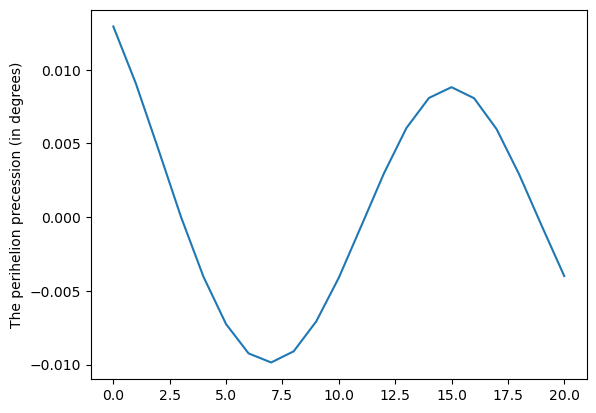

In [21]:
plt.plot(peri_precession_per_orbit_list)
plt.ylabel('The perihelion precession (in degrees)')
plt.show()

In [25]:
# As an attempt to calculate the perihelion precession:

# The values were drawn into a long line of degrees, compared to the time
# Then the relation is fitted (linear relation)

omega_deg = np.degrees(omega_values) * 3600 # arcseconds

time_years = np.array(epochs) / (100 * 3600 * 24 * 365.25)

coeffs = np.polyfit(
    time_years,
    omega_deg,
    1
)

slope_deg_per_century = coeffs[0]
print(f"Perihelion precession of: {slope_deg_per_century:4f} arcseconds / century")
# print(coeffs)

Perihelion precession of: 3941.152709 arcseconds / century


In [24]:
# Second attempt:

# omega_deg = np.degrees(omega_values) * 3600 # arcseconds
# time_years = np.array(epochs) / (100 * 3600 * 24 * 365.25)

perihelion_test = np.array(peri_precession_per_orbit_list) * 3600
epoch_test = np.array(epoch_perihelion_list) / (100 * 3600 * 24 * 365.25)

coeffs_test = np.polyfit(
    epoch_test,
    #time_years,
    perihelion_test,
    #omega_deg,
    1
)

slope_deg_per_century_test = coeffs_test[0]
print(f"Perihelion precession of: {slope_deg_per_century_test:4f} arcseconds / century")
# print(coeffs)

Perihelion precession of: 48.679926 arcseconds / century


Then to print and show the results:

In [17]:
# Then
# Step 7, run the simulation:

# # Using print commands to keep track of the code
# print("Now running the barycentric simulation...")
# results_barycentric = simulator.create_dynamics_simulator(body_system, propagator_settings_barycentric).state_history


In [18]:
# # Step 8: Plot the results 
# # First the barycentric, then the hierarchical

# print("Start of barycentric plot")

# barycentric_array = result2array(results_barycentric)

# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection='3d')
# ax.set_title('Solar System + 1998 TU3 Trajectories (Barycentric)')

# for i, body in enumerate(bodies_to_propagate):
#     # Each body has 6 columns (x, y, z, vx, vy, vz) + 1 for time
#     ax.plot(barycentric_array[:, 6*i+1], barycentric_array[:, 6*i+2], barycentric_array[:, 6*i+3], label=body)

# ax.scatter(0, 0, 0, marker='o', color='yellow', label="SSB/Sun Center")
# ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
# ax.set_xlabel('x [m]')
# ax.set_ylabel('y [m]')
# ax.set_zlabel('z [m]')

# # Alter the limits depending on what you wish to see (Mars is at ~2.0E11 while Naptune can be seen at ~2.0E12)
# limit = 2.0E11
# ax.set_xlim([-limit, limit])
# ax.set_ylim([-limit, limit])
# ax.set_zlim([-limit, limit])

# plt.tight_layout()
# plt.show()

# print("End of barycentric plot")



In [19]:
# # Now for the hierarchical data
# print("Now running the hierarchical simulation...")
# results_hierarchical = simulator.create_dynamics_simulator(body_system, propagator_settings_hierarchical).state_history

# # Convert results to array once more
# hierarchical_system_state_array = result2array(results_hierarchical)

# print("Start of hierarchical figures")
# # Create a taller figure for four subplots
# fig1 = plt.figure(figsize=(14, 14))

# # --- Subplot 1: Sun w.r.t SSB ---
# ax1 = fig1.add_subplot(221, projection='3d')
# ax1.set_title('1. Trajectory of the Sun w.r.t SSB')
# ax1.scatter(0, 0, 0, marker='x', label="SSB", color='black')

# # --- Subplot 2: Planets & TU3 w.r.t Sun (Overview) ---
# ax2 = fig1.add_subplot(222, projection='3d')
# ax2.set_title('2. Global Solar System w.r.t Sun')
# ax2.scatter(0, 0, 0, marker='o', label="Sun", color='orange')

# # # --- Subplot 3: Moon w.r.t Earth ---
# # ax3 = fig1.add_subplot(223, projection='3d')
# # ax3.set_title('3. Trajectory of the Moon w.r.t Earth')
# # ax3.scatter(0, 0, 0, marker='o', label="Earth", color='blue')

# # --- Subplot 4: 1998 TU3 w.r.t Sun (Isolated) ---
# ax4 = fig1.add_subplot(224, projection='3d')
# ax4.set_title('4. Isolated Orbit of 1998 TU3 w.r.t Sun')
# ax4.scatter(0, 0, 0, marker='o', label="Sun", color='orange')

# for i, body in enumerate(bodies_to_propagate):
#     x = hierarchical_system_state_array[:, 6 * i + 1]
#     y = hierarchical_system_state_array[:, 6 * i + 2]
#     z = hierarchical_system_state_array[:, 6 * i + 3]

#     if body == "Sun":
#         ax1.plot(x, y, z, label=body)
#     # elif body == "Moon":
#     #     ax3.plot(x, y, z, label=body)
#     elif body == "1998-TU3":
#         # Plot TU3 in the global view (ax2) AND the isolated view (ax4)
#         ax2.plot(x, y, z, label=body, linestyle='--')
#         ax4.plot(x, y, z, label=body, linestyle='--', color='red')
#     else:
#         # All other planets go to the global view
#         ax2.plot(x, y, z, label=body)

# # Define limits for each subplot [m]
# ax_lims = [
#     [-2.0E9, 2.0E9],    # 1. Sun's wobble
#     [-2.0E12, 2.0E12],  # 2. Solar system overview
#     [-5.0E8, 5.0E8],    # 3. Lunar orbit
#     [-2.0E11, 2.0E11]   # 4. TU3 orbit (Zoomed in on its orbit)
# ]

# axs = [ax1, ax2, ax4]

# for ax, ax_lim in zip(axs, ax_lims):
#     ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
#     ax.set_xlabel('x [m]')
#     ax.set_ylabel('y [m]')
#     ax.set_zlabel('z [m]')
#     ax.set_xlim(ax_lim)
#     ax.set_ylim(ax_lim)
#     ax.set_zlim(ax_lim)

# plt.tight_layout()
# plt.show()

# print("End of hierarchical figures")